# 07 — Homography Improvement
Replace the 5-point circle-based homography with a manually selected 10-point polygon spanning the full floor area.

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, '..')
from src.heatmap import FLOOR_W, FLOOR_H, cx, cy, R, make_floor_canvas, project_points, build_heatmap

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')

## Reference points and reprojection errors

In [2]:
# Original 5-point baseline (circle cardinals + palm tree)
src_base = np.float32([
    [206, 378], [432, 248], [138, 272], [500, 339], [321, 139],
])
dst_base = np.float32([
    [cx,     cy + R],
    [cx,     cy - R],
    [cx - R, cy    ],
    [cx + R, cy    ],
    [cx,     510   ],
])
H_base, _ = cv2.findHomography(src_base, dst_base, method=0)

# New 10-point polygon — manually selected, spanning full floor depth and width
src_new = np.float32([
    [ 95, 214], [121, 152], [118, 105], [114,  39],
    [369,  25], [499, 106], [536, 143], [577, 204],
    [608, 296], [638, 415],
])
dst_new = np.float32([
    [342, 681], [369, 552], [354, 409], [325, 206],
    [564, 202], [666, 403], [691, 552], [700, 699],
    [704, 860], [705, 1056],
])
H_new, _ = cv2.findHomography(src_new, dst_new, method=0)

def reprojection_errors(H, src, dst):
    proj = project_points(src, H)
    return np.linalg.norm(proj - dst, axis=1)

errs_base = reprojection_errors(H_base, src_base, dst_base)
errs_new  = reprojection_errors(H_new,  src_new,  dst_new)

print(f'Baseline 5-pt RMS : {np.sqrt((errs_base**2).mean()):.1f}px')
print(f'New 10-pt RMS     : {np.sqrt((errs_new**2).mean()):.1f}px\n')
print(f'{"Point":<8} {"Error":>10}')
for i, e in enumerate(errs_new):
    print(f'P{i+1:<7} {e:>10.1f}px')

Baseline 5-pt RMS : 36.0px
New 10-pt RMS     : 16.2px

Point         Error
P1              8.7px
P2             15.5px
P3              7.0px
P4              8.2px
P5             14.9px
P6             37.8px
P7             14.2px
P8             17.7px
P9              5.2px
P10             2.0px


## Heatmap comparison

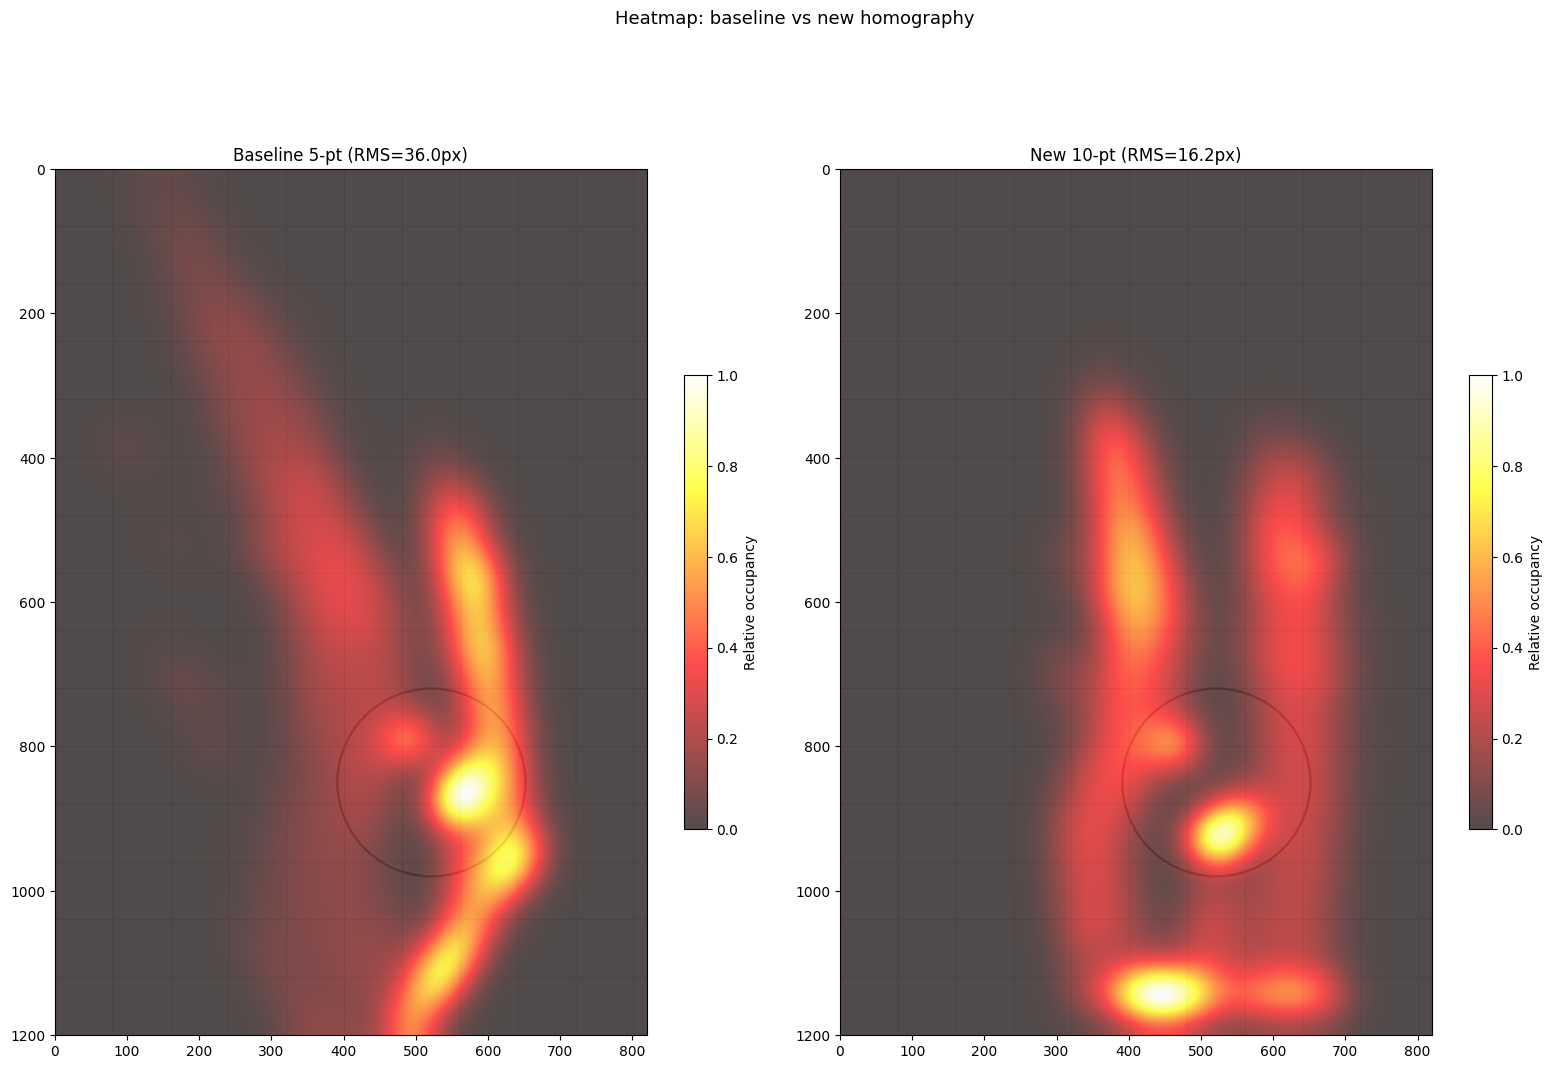

In [3]:
detections = pd.read_csv('../data/interim/detections.csv')
pts_cam = detections[['x', 'y']].values

def make_heatmap(pts, H):
    proj = project_points(pts, H)
    in_bounds = (
        (proj[:, 0] >= 0) & (proj[:, 0] <= FLOOR_W) &
        (proj[:, 1] >= 0) & (proj[:, 1] <= FLOOR_H)
    )
    proj_df = pd.DataFrame({'px': proj[in_bounds, 0], 'py': proj[in_bounds, 1]})
    return build_heatmap(proj_df)

hm_base = make_heatmap(pts_cam, H_base)
hm_new  = make_heatmap(pts_cam, H_new)

fig, axes = plt.subplots(1, 2, figsize=(16, 12))
for ax, hm, title in zip(axes, [hm_base, hm_new],
                          [f'Baseline 5-pt (RMS={np.sqrt((errs_base**2).mean()):.1f}px)',
                           f'New 10-pt (RMS={np.sqrt((errs_new**2).mean()):.1f}px)']):
    ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
    im = ax.imshow(hm, extent=[0, FLOOR_W, FLOOR_H, 0], cmap='hot', alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.4, label='Relative occupancy')
    ax.grid(False)
    ax.set_title(title, fontsize=12)
plt.suptitle('Heatmap: baseline vs new homography', fontsize=13)
plt.tight_layout()
plt.show()

## Save new homography

In [4]:
np.save(PROCESSED / 'homography.npy', H_new)
print(f'Saved new homography. RMS: {np.sqrt((errs_base**2).mean()):.1f} → {np.sqrt((errs_new**2).mean()):.1f}px')

Saved new homography. RMS: 36.0 → 16.2px
